In [1]:
import pandas as pd
from SCPIntModel import *

In [2]:
import scanpy as sc

In [3]:
multibatch_ann = sc.read_h5ad('../data/task_data/human_brain.h5ad')

In [4]:
multibatch_ann

AnnData object with n_obs × n_vars = 1505 × 4705
    obs: 'ID', 'celltype', 'sample', 'batch'
    var: 'mean', 'std'
    uns: 'batch_colors', 'celltype_colors', 'neighbors', 'pca', 'sample_colors', 'tsne', 'umap'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [5]:
processor = AnnDataProcessor(multibatch_ann, batch_key="batch")

Loaded 1505 cells × 4705 proteins
Batches (3): ['GW13', 'GW15', 'GW19']


In [6]:
loader  = processor.make_dataloader(batch_size=128)

In [7]:
 # 构建模型
model = scProteoIntegrator(
    n_genes   = processor.n_genes,
    n_batches = processor.n_batches,
)

In [8]:
lambda_cls=0.3
lambda_adv=2
lambda_mse=1e-5
lr = 0.01
epochs = 1000
warmup = 1
md = 'human'

In [9]:
trainer = Trainer(model, lr=lr, lambda_cls=lambda_cls, lambda_adv=lambda_adv,lambda_mse=lambda_mse, lr_reduc_factor=0.9)

In [10]:
trainer.fit(loader, n_epochs=epochs, adv_warmup_epochs=warmup)

Epoch   10 | total=2.9704 | recon=0.8269 | mse=0.7219 | cls=0.1157 | adv=1.0544 |lr=0.01
Epoch   20 | total=6.9457 | recon=0.1401 | mse=0.6904 | cls=0.2293 | adv=3.3684 |lr=0.009000000000000001
Epoch   30 | total=26.2901 | recon=0.2971 | mse=0.7223 | cls=0.5755 | adv=12.9102 |lr=0.008100000000000001
Epoch   40 | total=19.3777 | recon=0.1505 | mse=0.7252 | cls=0.5018 | adv=9.5383 |lr=0.006561000000000002
Epoch   50 | total=10.1961 | recon=0.0125 | mse=0.7238 | cls=0.1914 | adv=5.0631 |lr=0.005314410000000002
Epoch   60 | total=7.6076 | recon=0.0151 | mse=0.7196 | cls=0.1474 | adv=3.7742 |lr=0.004782969000000002
Epoch   70 | total=8.0521 | recon=-0.0661 | mse=0.7249 | cls=0.1822 | adv=4.0318 |lr=0.003874204890000002
Epoch   80 | total=9.8846 | recon=-0.1840 | mse=0.7221 | cls=0.1238 | adv=5.0157 |lr=0.003138105960900002
Epoch   90 | total=8.2897 | recon=-0.0792 | mse=0.7178 | cls=0.1126 | adv=4.1675 |lr=0.0028242953648100018
Epoch  100 | total=3.7736 | recon=-0.2710 | mse=0.7157 | cls=0.

In [11]:
model_name = f"{md}_cls-{lambda_cls}_adv-{lambda_adv}_mse-{lambda_mse}_warmup-{warmup}_lr-{lr}_epoch-{epochs}"

损失曲线已保存至: ../data/model/human_cls-0.3_adv-2_mse-1e-05_warmup-1_lr-0.01_epoch-1000.svg


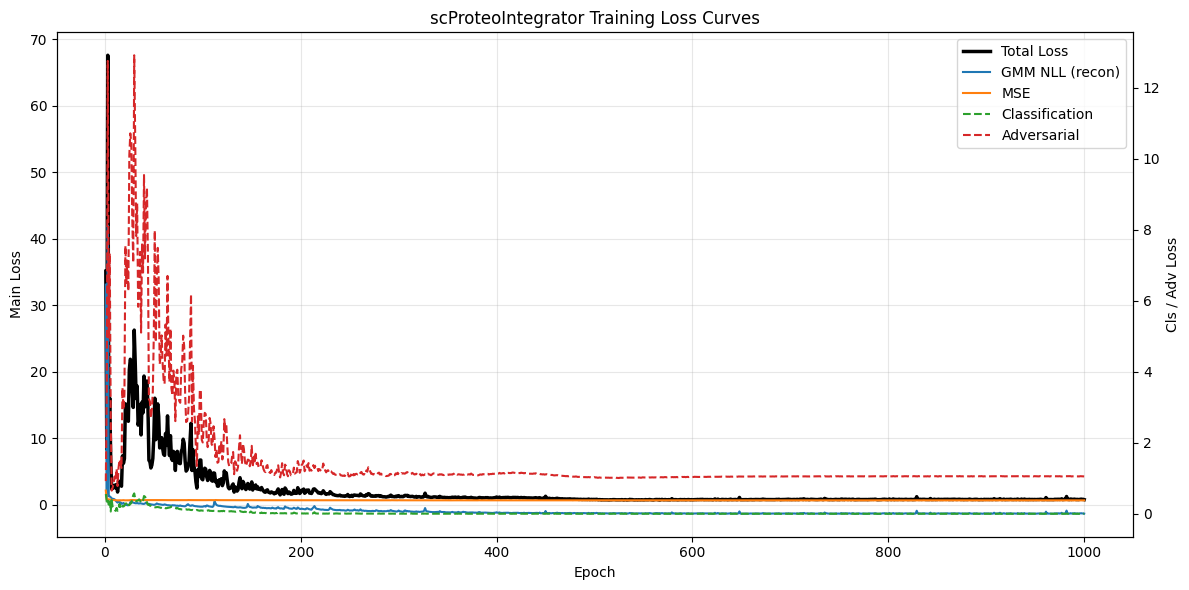

In [12]:
trainer.plot_losses(
    save_path=f"../data/model/{model_name}.svg",   # 可改成任意路径
    show=True                      # False 则只保存不弹窗
)

In [13]:
trainer.save(f"../data/model/{model_name}.pt")

Model saved to ../data/model/human_cls-0.3_adv-2_mse-1e-05_warmup-1_lr-0.01_epoch-1000.pt
